# Farm use case LLM scalability

In [6]:
%cd ..

C:\Users\micha\OneDrive - Univerzita Karlova\research\2024-LLM-DEECo\llm-adaptation


In [7]:
%pwd  # should be "llm-adaptation"

'C:\\Users\\micha\\OneDrive - Univerzita Karlova\\research\\2024-LLM-DEECo\\llm-adaptation'

## Run the experiment

In [3]:
import subprocess

def run(llm_config, scale_config, variant_conf):
    configs = ["farm/configs/default.yaml", "farm/configs/config_no_battery.yaml", "farm/configs/scalability/scale.yaml", "configs/jinja.yaml", "DSL/drones.yaml", f"configs/{llm_config}.yaml", "farm/configs/no_battery_llm.yaml", "farm/configs/simulation_description_2.yaml"] + variant_conf + ["configs/retry2.yaml", f"farm/configs/scalability/{scale_config}.yaml"]  # without strategy
    run = ["python", "main.py", *configs, "-e", "1", "-s", "1"]

    print(" ".join(run))
    return  # remove this line to actually run the experiment using subprocess (this will only output the run parameters)

    # result = subprocess.run(run, capture_output=False)
    result = subprocess.run(run, capture_output=True)
    stdout = result.stdout.decode("utf-8")
    print(stdout.partition("Simulation done")[2])

    stderr = result.stderr.decode("utf-8")
    if (stderr):
        print(stderr)

### GPT-4o mini

In [4]:
import itertools

params_gpt4omini = {
    "scale": ["scale1", "scale3", "scale10", "scale20", "scale57", "scale116"],
    "variant": [[], ["farm/configs/step_by_step_multiple.yaml"], ["farm/configs/strategy_multiple.yaml"], ["farm/configs/strategy_multiple.yaml", "configs/ensemble_first_component_retry.yaml"]]
}
grid_gpt4omini = list(itertools.product(*params_gpt4omini.values()))
print(len(grid_gpt4omini))

24


In [5]:
for scale, variant in grid_gpt4omini:
    run("llm_gpt4omini", scale, variant)

python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_gpt4omini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml configs/retry2.yaml farm/configs/scalability/scale1.yaml -e 1 -s 1
python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_gpt4omini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml farm/configs/step_by_step_multiple.yaml configs/retry2.yaml farm/configs/scalability/scale1.yaml -e 1 -s 1
python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_gpt4omini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml farm/configs/strategy_multiple.yaml configs/retry2.yaml farm/configs/scal

### o3-mini

In [6]:
params_o3mini = {
    "scale": ["scale1", "scale5", "scale17", "scale35", "scale90", "scale180"],
    "variant": [[], ["farm/configs/step_by_step_multiple.yaml"], ["farm/configs/strategy_multiple.yaml"]]
}
grid_o3mini = list(itertools.product(*params_o3mini.values()))
print(len(grid_o3mini))

18


In [7]:
for scale, variant in grid_o3mini:
    run("llm_o3mini", scale, variant)

python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_o3mini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml configs/retry2.yaml farm/configs/scalability/scale1.yaml -e 1 -s 1
python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_o3mini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml farm/configs/step_by_step_multiple.yaml configs/retry2.yaml farm/configs/scalability/scale1.yaml -e 1 -s 1
python main.py farm/configs/default.yaml farm/configs/config_no_battery.yaml farm/configs/scalability/scale.yaml configs/jinja.yaml DSL/drones.yaml configs/llm_o3mini.yaml farm/configs/no_battery_llm.yaml farm/configs/simulation_description_2.yaml farm/configs/strategy_multiple.yaml configs/retry2.yaml farm/configs/scalability/s

## Results

### Load data

In [8]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statistics
sns.set_theme()

In [9]:
# results_folder = Path("./logs/no_battery/scale")
results_folder = Path("./results/scale")

In [10]:
results_files = sorted(results_folder.glob("*/*.llm.csv"))
print(len(results_files), "files found")

55 files found


In [125]:
datas = []

In [126]:
for file in results_files:
    try:
        name = file.stem
        if "jinja_" not in name:
            continue

        data = pd.read_csv(file, low_memory=False)
        stats_file = file.parent / name.replace(".llm", ".csv")
        stats = pd.read_csv(stats_file, low_memory=False)
        damage = stats.iloc[299]["damage"]

        parts = name.split("_")
        llm = parts[1]
        scale = parts[-1].split(".")[0]
        params = parts[2:-1]
        params = ",\n".join(params)

        if "efcr" in params:
            variant = "ensemble-first"
        elif "strategy" in params:
            variant = "high"
        # elif "step-by-step" in params:
        elif "step-by-step" in params:
            if "V2" in params:
                variant = "low"
            else:
                continue
        else:
            variant = "zero"

        # Choose whether to use the variant or not in charts below
        # data["llm"] = llm
        data["llm"] = llm + "_" + variant

        data["llm_variant"] = llm + "_" + variant
        data["llm_only"] = llm
        data["scale"] = scale
        data["params"] = params
        data["damage"] = damage

        # counts of drones in state
        steps = stats[stats["step"].isin(data["step"])]
        data["protecting"] = np.nan
        data["idle"] = np.nan
        data["moving_to_field"] = np.nan
        mask = data["try"] == 0
        data.loc[mask, "protecting"] = steps["PROTECTING"].values
        data.loc[mask, "idle"] = steps["IDLE"].values
        data.loc[mask, "moving_to_field"] = steps["MOVING_TO_FIELD"].values

        datas.append(data)

    except pd.errors.EmptyDataError:
        print("Skipping empty file", file)
    except IndexError:
        print("Index error in file", file)

In [127]:
summary = pd.concat(datas, ignore_index=True)
summary

,step,try,errors,input_tokens,output_tokens,reasoning_tokens,response_time,llm,llm_variant,llm_only,scale,params,damage,protecting,idle,moving_to_field
0,1,0,0,1160,423,0,8.343977,gpt4omini_zero,gpt4omini_zero,gpt4omini,scale1,"sd2,\nretry2",310,0.0,4.0,4.0
1,11,0,0,1200,453,0,7.115220,gpt4omini_zero,gpt4omini_zero,gpt4omini,scale1,"sd2,\nretry2",310,2.0,2.0,4.0
2,21,0,0,1218,457,0,9.499124,gpt4omini_zero,gpt4omini_zero,gpt4omini,scale1,"sd2,\nretry2",310,4.0,1.0,3.0
3,31,0,0,1223,333,0,4.903902,gpt4omini_zero,gpt4omini_zero,gpt4omini,scale1,"sd2,\nretry2",310,7.0,0.0,1.0
4,41,0,0,1232,524,0,10.714981,gpt4omini_zero,gpt4omini_zero,gpt4omini,scale1,"sd2,\nretry2",310,6.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2004,251,1,0,52416,6403,2112,52.587189,o3mini_high,o3mini_high,o3mini,scale90,"sd2,\nstrategyMultiple,\nretry2",7784,NaN,NaN,NaN
2005,261,0,0,47824,6879,2624,50.481284,o3mini_high,o3mini_high,o3mini,scale90,"sd2,\nstrategyMultiple,\nretry2",7784,0.0,688.0,12.0
2006,271,0,0,47848,6943,2688,48.294579,o3mini_high,o3mini_high,o3mini,scale90,"sd2,\nstrategyMultiple,\nretry2",7784,0.0,688.0,12.0
2007,281,0,0,48054,5791,1536,47.294544,o3mini_high,o3mini_high,o3mini,scale90,"sd2,\nstrategyMultiple,\nretry2",7784,1.0,688.0,11.0


In [128]:
summary['original_scale'] = summary['scale'].apply(lambda s: int(s.split("scale")[-1]))
summary['original_scale_str'] = summary['scale']
summary['scale'] = summary.apply(lambda row: {
    ("gpt4omini", "scale1"): 1,
    ("gpt4omini", "scale3"): 2,
    ("gpt4omini", "scale5"): 3,
    ("gpt4omini", "scale10"): 5,
    ("gpt4omini", "scale20"): 10,
    ("gpt4omini", "scale57"): 25,
    ("gpt4omini", "scale116"): 50,
    ("o3mini", "scale1"): 0.6,
    ("o3mini", "scale3"): 1,
    ("o3mini", "scale5"): 2,
    ("o3mini", "scale17"): 5,
    ("o3mini", "scale35"): 10,
    ("o3mini", "scale90"): 25,
    ("o3mini", "scale180"): 50,
}[(row['llm_only'], row['scale'])], axis=1)

In [129]:
summary.to_csv(results_folder / "summary.csv", index=False)

In [11]:
summary = pd.read_csv(results_folder / "summary.csv")
summary

,step,try,errors,input_tokens,output_tokens,reasoning_tokens,response_time,llm,llm_variant,llm_only,scale,params,damage,protecting,idle,moving_to_field,original_scale,original_scale_str
0,1,0,0,1160,423,0,8.343977,gpt4omini_zero,gpt4omini_zero,gpt4omini,1.0,"sd2,\r\nretry2",310,0.0,4.0,4.0,1,scale1
1,11,0,0,1200,453,0,7.115220,gpt4omini_zero,gpt4omini_zero,gpt4omini,1.0,"sd2,\r\nretry2",310,2.0,2.0,4.0,1,scale1
2,21,0,0,1218,457,0,9.499124,gpt4omini_zero,gpt4omini_zero,gpt4omini,1.0,"sd2,\r\nretry2",310,4.0,1.0,3.0,1,scale1
3,31,0,0,1223,333,0,4.903902,gpt4omini_zero,gpt4omini_zero,gpt4omini,1.0,"sd2,\r\nretry2",310,7.0,0.0,1.0,1,scale1
4,41,0,0,1232,524,0,10.714981,gpt4omini_zero,gpt4omini_zero,gpt4omini,1.0,"sd2,\r\nretry2",310,6.0,1.0,1.0,1,scale1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2004,251,1,0,52416,6403,2112,52.587189,o3mini_high,o3mini_high,o3mini,25.0,"sd2,\r\nstrategyMultiple,\r\nretry2",7784,NaN,NaN,NaN,90,scale90
2005,261,0,0,47824,6879,2624,50.481284,o3mini_high,o3mini_high,o3mini,25.0,"sd2,\r\nstrategyMultiple,\r\nretry2",7784,0.0,688.0,12.0,90,scale90
2006,271,0,0,47848,6943,2688,48.294579,o3mini_high,o3mini_high,o3mini,25.0,"sd2,\r\nstrategyMultiple,\r\nretry2",7784,0.0,688.0,12.0,90,scale90
2007,281,0,0,48054,5791,1536,47.294544,o3mini_high,o3mini_high,o3mini,25.0,"sd2,\r\nstrategyMultiple,\r\nretry2",7784,1.0,688.0,11.0,90,scale90


In [12]:
print("Ran experiments: table shows number of steps (should be 30)")
pivot = summary[summary["try"] == 0].pivot_table(values='step', index='llm', columns='scale', aggfunc='count', fill_value=0)
pivot

Ran experiments: table shows number of steps (should be 30)


scale,0.6,1.0,2.0,3.0,5.0,10.0,25.0,50.0
llm,,,,,,,,
gpt4omini_ensemble-first,0,30,30,30,30,30,30,30
gpt4omini_high,0,30,30,30,30,30,30,30
gpt4omini_low,0,30,30,30,30,30,30,30
gpt4omini_zero,0,30,30,30,30,30,30,30
o3mini_high,30,30,30,0,30,30,30,30
o3mini_low,30,30,30,0,30,30,30,30
o3mini_zero,30,30,30,0,30,30,30,30


### Process results

In [105]:
results = pd.DataFrame(columns=["llm_variant", "scale", "fields", "drones", "reasoning_tokens", "answer_tokens", "cost", "retry_rate", "second_retry_rate", "assigned_drones", "assigned_to_protection", "protecting", "response_time"])
for llm in summary["llm"].unique():
    for scale in sorted(summary.loc[summary["llm"] == llm,"scale"].unique()):
        results.loc[len(results)] = pd.Series()
        results.loc[len(results)-1, "llm_variant"] = llm
        results.loc[len(results)-1, "scale"] = scale
results.set_index(["llm_variant", "scale"], inplace=True)
results

fields drones reasoning_tokens answer_tokens  \
llm_variant              scale                                                
gpt4omini_zero           1.0      NaN    NaN              NaN           NaN   
                         2.0      NaN    NaN              NaN           NaN   
                         3.0      NaN    NaN              NaN           NaN   
                         5.0      NaN    NaN              NaN           NaN   
                         10.0     NaN    NaN              NaN           NaN   
                         25.0     NaN    NaN              NaN           NaN   
                         50.0     NaN    NaN              NaN           NaN   
gpt4omini_low            1.0      NaN    NaN              NaN           NaN   
                         2.0      NaN    NaN              NaN           NaN   
                         3.0      NaN    NaN              NaN           NaN   
                         5.0      NaN    NaN              NaN           NaN   
                         10.0     NaN    NaN              NaN           NaN   
                         25.0     NaN    NaN              NaN           NaN   
                         50.0     NaN    NaN              NaN           NaN   
gpt4omini_high           1.0      NaN    NaN              NaN           NaN   
                         2.0      NaN    NaN              NaN           NaN   
                         3.0      NaN    NaN              NaN           NaN   
                         5.0      NaN    NaN              NaN           NaN   
                         10.0     NaN    NaN              NaN           NaN   
                         25.0     NaN    NaN              NaN           NaN   
                         50.0     NaN    NaN              NaN           NaN   
gpt4omini_ensemble-first 1.0      NaN    NaN              NaN           NaN   
                         2.0      NaN    NaN              NaN           NaN   
                         3.0      NaN    NaN              NaN           NaN   
                         5.0      NaN    NaN              NaN           NaN   
                         10.0     NaN    NaN              NaN           NaN   
                         25.0     NaN    NaN              NaN           NaN   
                         50.0     NaN    NaN              NaN           NaN   
o3mini_zero              0.6      NaN    NaN              NaN           NaN   
                         1.0      NaN    NaN              NaN           NaN   
                         2.0      NaN    NaN              NaN           NaN   
                         5.0      NaN    NaN              NaN           NaN   
                         10.0     NaN    NaN              NaN           NaN   
                         25.0     NaN    NaN              NaN           NaN   
                         50.0     NaN    NaN              NaN           NaN   
o3mini_low               0.6      NaN    NaN              NaN           NaN   
                         1.0      NaN    NaN              NaN           NaN   
                         2.0      NaN    NaN              NaN           NaN   
                         5.0      NaN    NaN              NaN           NaN   
                         10.0     NaN    NaN              NaN           NaN   
                         25.0     NaN    NaN              NaN           NaN   
                         50.0     NaN    NaN              NaN           NaN   
o3mini_high              0.6      NaN    NaN              NaN           NaN   
                         1.0      NaN    NaN              NaN           NaN   
                         2.0      NaN    NaN              NaN           NaN   
                         5.0      NaN    NaN              NaN           NaN   
                         10.0     NaN    NaN              NaN           NaN   
                         25.0     NaN    NaN              NaN           NaN   
                         50.0     NaN    NaN              NaN           NaN   

 

In [106]:
for llm in summary["llm"].unique():
    if "gpt4omini" in llm:
        results.loc[(llm, 1), ["fields", "drones"]] = [4, 8]
        results.loc[(llm, 2), ["fields", "drones"]] = [12, 24]
        results.loc[(llm, 3), ["fields", "drones"]] = [20, 40]
        results.loc[(llm, 5), ["fields", "drones"]] = [40, 79]
        results.loc[(llm, 10), ["fields", "drones"]] = [80, 162]
        results.loc[(llm, 25), ["fields", "drones"]] = [228, 437]
        results.loc[(llm, 50), ["fields", "drones"]] = [464, 881]
    else:
        results.loc[(llm, 0.6), ["fields", "drones"]] = [4, 8]
        results.loc[(llm, 1), ["fields", "drones"]] = [12, 24]
        results.loc[(llm, 2), ["fields", "drones"]] = [20, 40]
        results.loc[(llm, 5), ["fields", "drones"]] = [68, 117]
        results.loc[(llm, 10), ["fields", "drones"]] = [140, 269]
        results.loc[(llm, 25), ["fields", "drones"]] = [360, 700]
        results.loc[(llm, 50), ["fields", "drones"]] = [720, 1388]
results

fields drones reasoning_tokens answer_tokens  \
llm_variant              scale                                                
gpt4omini_zero           1.0        4      8              NaN           NaN   
                         2.0       12     24              NaN           NaN   
                         3.0       20     40              NaN           NaN   
                         5.0       40     79              NaN           NaN   
                         10.0      80    162              NaN           NaN   
                         25.0     228    437              NaN           NaN   
                         50.0     464    881              NaN           NaN   
gpt4omini_low            1.0        4      8              NaN           NaN   
                         2.0       12     24              NaN           NaN   
                         3.0       20     40              NaN           NaN   
                         5.0       40     79              NaN           NaN   
                         10.0      80    162              NaN           NaN   
                         25.0     228    437              NaN           NaN   
                         50.0     464    881              NaN           NaN   
gpt4omini_high           1.0        4      8              NaN           NaN   
                         2.0       12     24              NaN           NaN   
                         3.0       20     40              NaN           NaN   
                         5.0       40     79              NaN           NaN   
                         10.0      80    162              NaN           NaN   
                         25.0     228    437              NaN           NaN   
                         50.0     464    881              NaN           NaN   
gpt4omini_ensemble-first 1.0        4      8              NaN           NaN   
                         2.0       12     24              NaN           NaN   
                         3.0       20     40              NaN           NaN   
                         5.0       40     79              NaN           NaN   
                         10.0      80    162              NaN           NaN   
                         25.0     228    437              NaN           NaN   
                         50.0     464    881              NaN           NaN   
o3mini_zero              0.6        4      8              NaN           NaN   
                         1.0       12     24              NaN           NaN   
                         2.0       20     40              NaN           NaN   
                         5.0       68    117              NaN           NaN   
                         10.0     140    269              NaN           NaN   
                         25.0     360    700              NaN           NaN   
                         50.0     720   1388              NaN           NaN   
o3mini_low               0.6        4      8              NaN           NaN   
                         1.0       12     24              NaN           NaN   
                         2.0       20     40              NaN           NaN   
                         5.0       68    117              NaN           NaN   
                         10.0     140    269              NaN           NaN   
                         25.0     360    700              NaN           NaN   
                         50.0     720   1388              NaN           NaN   
o3mini_high              0.6        4      8              NaN           NaN   
                         1.0       12     24              NaN           NaN   
                         2.0       20     40              NaN           NaN   
                         5.0       68    117              NaN           NaN   
                         10.0     140    269              NaN           NaN   
                         25.0     360    700              NaN           NaN   
                         50.0     720   1388              NaN           NaN   

 

In [107]:
summary['drones'] = summary.apply(lambda row: {
    ("gpt4omini", "scale1"): 8,
    ("gpt4omini", "scale3"): 24,
    ("gpt4omini", "scale5"): 40,
    ("gpt4omini", "scale10"): 79,
    ("gpt4omini", "scale20"): 162,
    ("gpt4omini", "scale57"): 437,
    ("gpt4omini", "scale116"): 881,
    ("o3mini", "scale1"): 8,
    ("o3mini", "scale3"): 24,
    ("o3mini", "scale5"): 40,
    ("o3mini", "scale17"): 117,
    ("o3mini", "scale35"): 269,
    ("o3mini", "scale90"): 700,
    ("o3mini", "scale180"): 1388,
}[(row['llm_only'], row['original_scale_str'])], axis=1)

In [108]:
initial = summary[summary["try"] == 0].copy()
initial

,step,try,errors,input_tokens,output_tokens,reasoning_tokens,response_time,llm,llm_variant,llm_only,scale,params,damage,protecting,idle,moving_to_field,original_scale,original_scale_str,drones
0,1,0,0,1160,423,0,8.343977,gpt4omini_zero,gpt4omini_zero,gpt4omini,1.0,"sd2,\r\nretry2",310,0.0,4.0,4.0,1,scale1,8
1,11,0,0,1200,453,0,7.115220,gpt4omini_zero,gpt4omini_zero,gpt4omini,1.0,"sd2,\r\nretry2",310,2.0,2.0,4.0,1,scale1,8
2,21,0,0,1218,457,0,9.499124,gpt4omini_zero,gpt4omini_zero,gpt4omini,1.0,"sd2,\r\nretry2",310,4.0,1.0,3.0,1,scale1,8
3,31,0,0,1223,333,0,4.903902,gpt4omini_zero,gpt4omini_zero,gpt4omini,1.0,"sd2,\r\nretry2",310,7.0,0.0,1.0,1,scale1,8
4,41,0,0,1232,524,0,10.714981,gpt4omini_zero,gpt4omini_zero,gpt4omini,1.0,"sd2,\r\nretry2",310,6.0,1.0,1.0,1,scale1,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2003,251,0,1,47817,8489,3968,60.096638,o3mini_high,o3mini_high,o3mini,25.0,"sd2,\r\nstrategyMultiple,\r\nretry2",7784,0.0,676.0,24.0,90,scale90,700
2005,261,0,0,47824,6879,2624,50.481284,o3mini_high,o3mini_high,o3mini,25.0,"sd2,\r\nstrategyMultiple,\r\nretry2",7784,0.0,688.0,12.0,90,scale90,700
2006,271,0,0,47848,6943,2688,48.294579,o3mini_high,o3mini_high,o3mini,25.0,"sd2,\r\nstrategyMultiple,\r\nretry2",7784,0.0,688.0,12.0,90,scale90,700
2007,281,0,0,48054,5791,1536,47.294544,o3mini_high,o3mini_high,o3mini,25.0,"sd2,\r\nstrategyMultiple,\r\nretry2",7784,1.0,688.0,11.0,90,scale90,700


### Errors

In [109]:
repeated = pd.DataFrame(columns=["llm", "scale", "try", "error_count", "error_rate", "response_time"])
for llm in summary["llm"].unique():
    for scale in summary["scale"].unique():
        for retry in (1, 2):
            count = len(summary[(summary["llm"] == llm) & (summary["scale"] == scale) & (summary["try"] == retry)])
            initial_count = len(summary[(summary["llm"] == llm) & (summary["scale"] == scale) & (summary["try"] == 0)])
            if initial_count > 0:
                avg_response_time = summary[(summary["llm"] == llm) & (summary["scale"] == scale) & (summary["try"] == retry)].response_time.mean()
                repeated.loc[len(repeated)] = [llm, scale, retry, count, count / initial_count, avg_response_time]
# repeated["error_rate"] = repeated["error_count"] / 30.0
repeated.sort_values(["llm", "scale", "try"], inplace=True)
repeated

,llm,scale,try,error_count,error_rate,response_time
42,gpt4omini_ensemble-first,1.0,1,13,0.433333,2.471428
43,gpt4omini_ensemble-first,1.0,2,8,0.266667,2.041910
50,gpt4omini_ensemble-first,2.0,1,23,0.766667,1.844524
51,gpt4omini_ensemble-first,2.0,2,7,0.233333,1.256474
52,gpt4omini_ensemble-first,3.0,1,29,0.966667,1.269715
...,...,...,...,...,...,...
63,o3mini_zero,10.0,2,0,0.000000,NaN
66,o3mini_zero,25.0,1,2,0.066667,34.996262
67,o3mini_zero,25.0,2,0,0.000000,NaN
60,o3mini_zero,50.0,1,2,0.066667,44.703919


In [110]:
repeated[repeated["try"] == 1]

,llm,scale,try,error_count,error_rate,response_time
42,gpt4omini_ensemble-first,1.0,1,13,0.433333,2.471428
50,gpt4omini_ensemble-first,2.0,1,23,0.766667,1.844524
52,gpt4omini_ensemble-first,3.0,1,29,0.966667,1.269715
44,gpt4omini_ensemble-first,5.0,1,30,1.000000,2.652137
48,gpt4omini_ensemble-first,10.0,1,30,1.000000,6.334905
54,gpt4omini_ensemble-first,25.0,1,27,0.900000,12.168925
46,gpt4omini_ensemble-first,50.0,1,25,0.833333,22.216778
28,gpt4omini_high,1.0,1,0,0.000000,NaN
36,gpt4omini_high,2.0,1,0,0.000000,NaN
38,gpt4omini_high,3.0,1,0,0.000000,NaN


In [111]:
print("Retry rate")
for _, row in repeated[repeated["try"] == 1].iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['error_rate']:.1%}")
    results.loc[(row['llm'], row['scale']), "retry_rate"] = f"{row['error_rate']:.0%}"

Retry rate
gpt4omini_ensemble-first, 1.0: 43.3%
gpt4omini_ensemble-first, 2.0: 76.7%
gpt4omini_ensemble-first, 3.0: 96.7%
gpt4omini_ensemble-first, 5.0: 100.0%
gpt4omini_ensemble-first, 10.0: 100.0%
gpt4omini_ensemble-first, 25.0: 90.0%
gpt4omini_ensemble-first, 50.0: 83.3%
gpt4omini_high, 1.0: 0.0%
gpt4omini_high, 2.0: 0.0%
gpt4omini_high, 3.0: 0.0%
gpt4omini_high, 5.0: 6.7%
gpt4omini_high, 10.0: 20.0%
gpt4omini_high, 25.0: 46.7%
gpt4omini_high, 50.0: 70.0%
gpt4omini_low, 1.0: 0.0%
gpt4omini_low, 2.0: 6.7%
gpt4omini_low, 3.0: 3.3%
gpt4omini_low, 5.0: 36.7%
gpt4omini_low, 10.0: 16.7%
gpt4omini_low, 25.0: 66.7%
gpt4omini_low, 50.0: 86.7%
gpt4omini_zero, 1.0: 0.0%
gpt4omini_zero, 2.0: 0.0%
gpt4omini_zero, 3.0: 0.0%
gpt4omini_zero, 5.0: 3.3%
gpt4omini_zero, 10.0: 6.7%
gpt4omini_zero, 25.0: 60.0%
gpt4omini_zero, 50.0: 73.3%
o3mini_high, 0.6: 0.0%
o3mini_high, 1.0: 0.0%
o3mini_high, 2.0: 0.0%
o3mini_high, 5.0: 3.3%
o3mini_high, 10.0: 3.3%
o3mini_high, 25.0: 20.0%
o3mini_high, 50.0: 40.0%
o3

In [112]:
print("Second retry rate")
for _, row in repeated[repeated["try"] == 2].iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['error_rate']:.1%}")
    results.loc[(row['llm'], row['scale']), "second_retry_rate"] = f"{row['error_rate']:.0%}"

Second retry rate
gpt4omini_ensemble-first, 1.0: 26.7%
gpt4omini_ensemble-first, 2.0: 23.3%
gpt4omini_ensemble-first, 3.0: 13.3%
gpt4omini_ensemble-first, 5.0: 40.0%
gpt4omini_ensemble-first, 10.0: 76.7%
gpt4omini_ensemble-first, 25.0: 66.7%
gpt4omini_ensemble-first, 50.0: 63.3%
gpt4omini_high, 1.0: 0.0%
gpt4omini_high, 2.0: 0.0%
gpt4omini_high, 3.0: 0.0%
gpt4omini_high, 5.0: 3.3%
gpt4omini_high, 10.0: 3.3%
gpt4omini_high, 25.0: 13.3%
gpt4omini_high, 50.0: 56.7%
gpt4omini_low, 1.0: 0.0%
gpt4omini_low, 2.0: 0.0%
gpt4omini_low, 3.0: 0.0%
gpt4omini_low, 5.0: 10.0%
gpt4omini_low, 10.0: 0.0%
gpt4omini_low, 25.0: 20.0%
gpt4omini_low, 50.0: 56.7%
gpt4omini_zero, 1.0: 0.0%
gpt4omini_zero, 2.0: 0.0%
gpt4omini_zero, 3.0: 0.0%
gpt4omini_zero, 5.0: 0.0%
gpt4omini_zero, 10.0: 0.0%
gpt4omini_zero, 25.0: 13.3%
gpt4omini_zero, 50.0: 53.3%
o3mini_high, 0.6: 0.0%
o3mini_high, 1.0: 0.0%
o3mini_high, 2.0: 0.0%
o3mini_high, 5.0: 0.0%
o3mini_high, 10.0: 0.0%
o3mini_high, 25.0: 0.0%
o3mini_high, 50.0: 10.0%


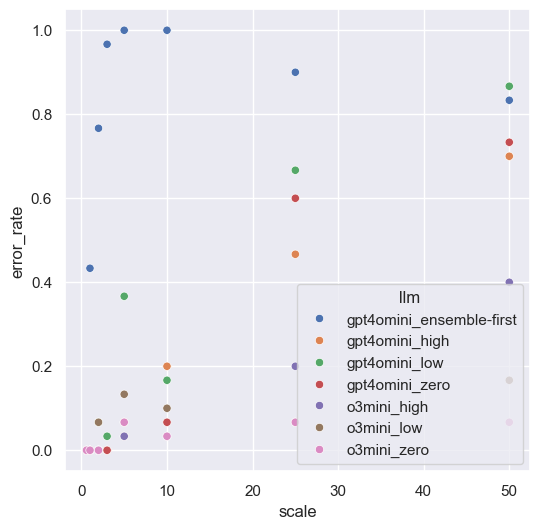

In [113]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="error_rate", hue="llm", data=repeated[repeated["try"] == 1], ax=ax, palette="deep")
plt.show()

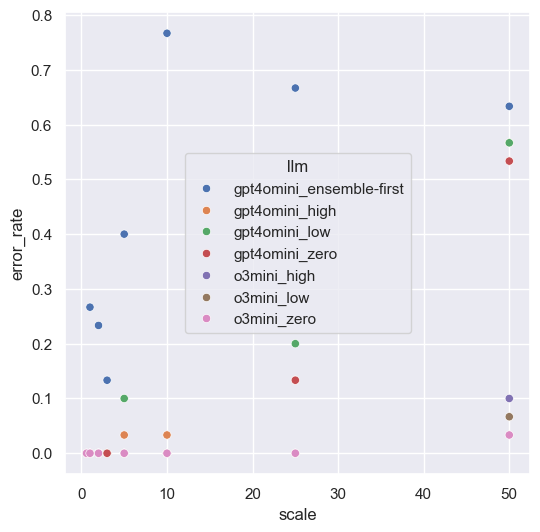

In [114]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="error_rate", hue="llm", data=repeated[repeated["try"] == 2], ax=ax, palette="deep")
plt.show()

### Time

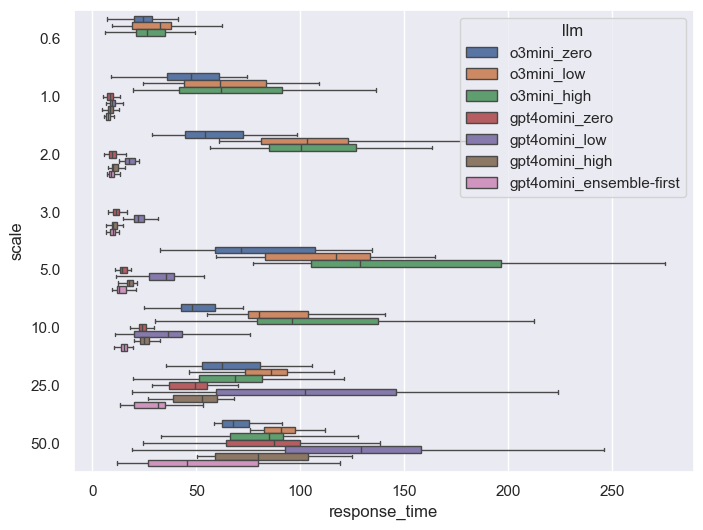

In [115]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="response_time", y="scale", hue="llm", data=initial, ax=ax, orient="h", showfliers=False)
plt.show()

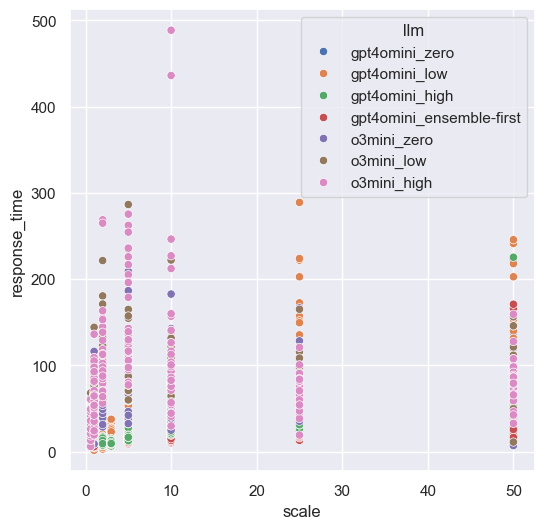

In [116]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="response_time", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

### Input tokens

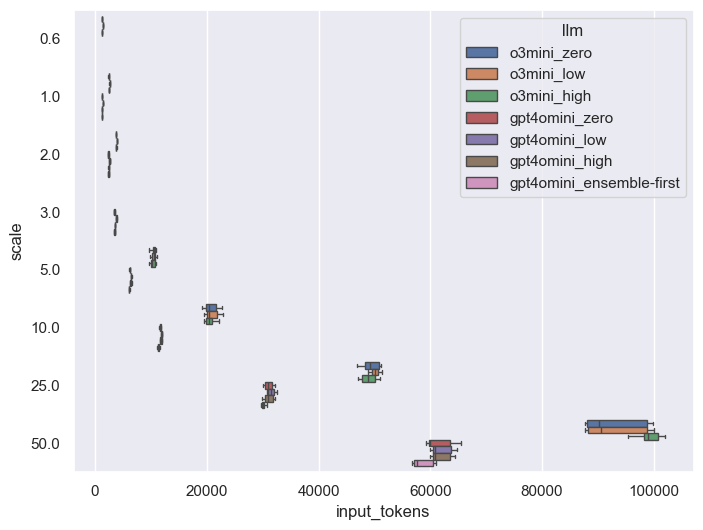

In [117]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="input_tokens", y="scale", hue="llm", data=initial, ax=ax, orient="h", showfliers=False)
plt.show()

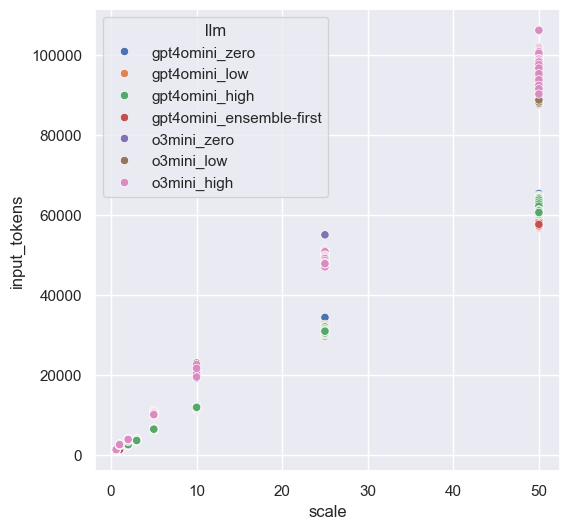

In [118]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="input_tokens", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

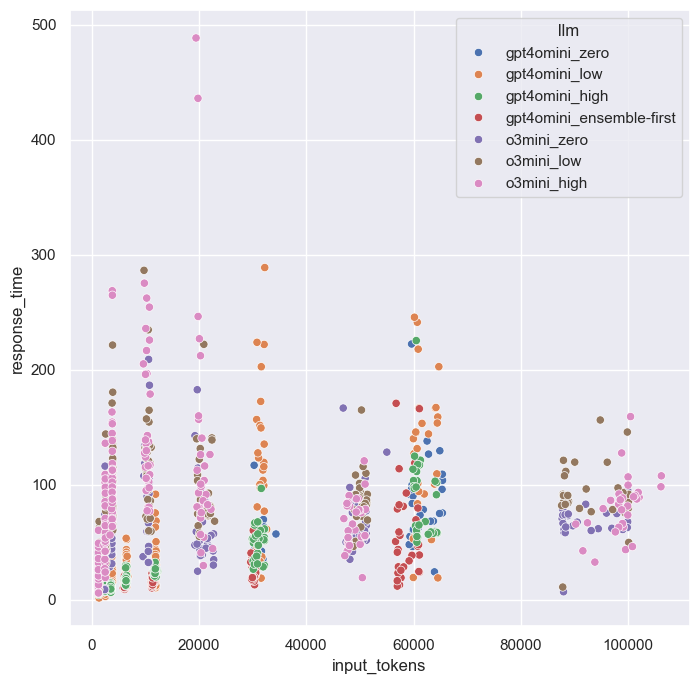

In [119]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="input_tokens", y="response_time", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

### Output tokens

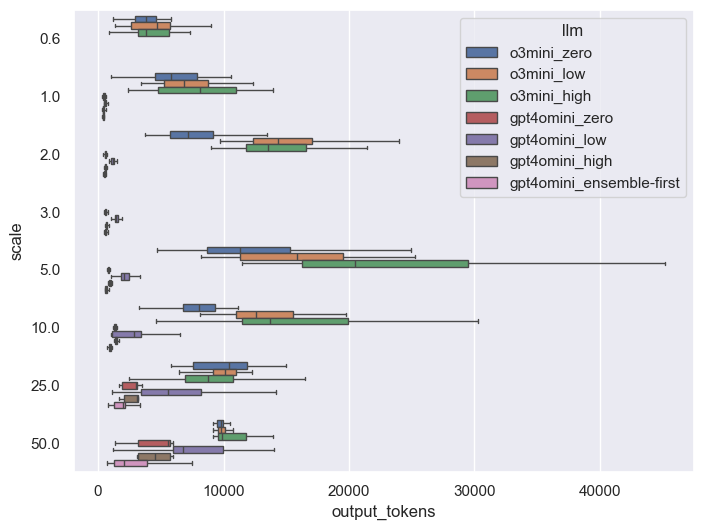

In [120]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="output_tokens", y="scale", hue="llm", data=initial, ax=ax, orient="h", showfliers=False)
plt.show()

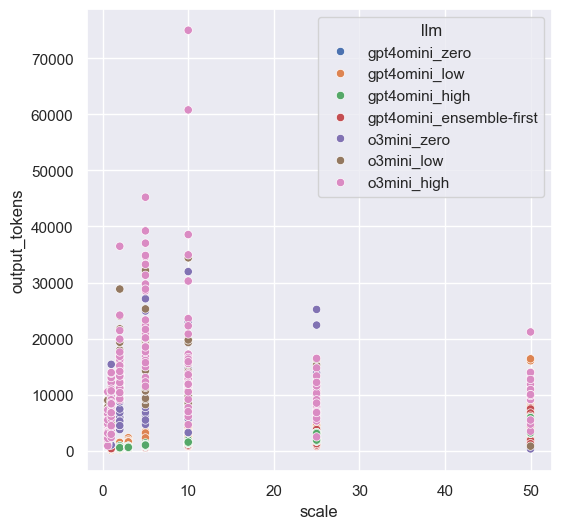

In [121]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="scale", y="output_tokens", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

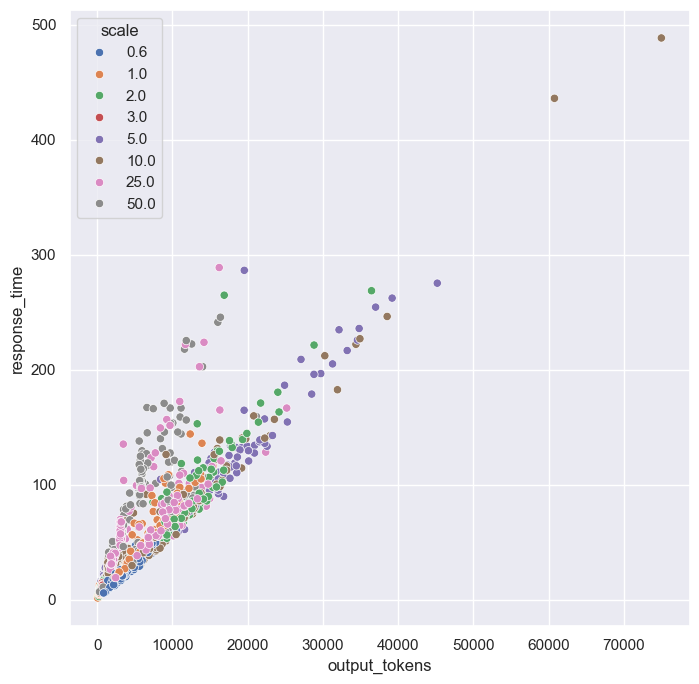

In [122]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="output_tokens", y="response_time", hue="scale", data=initial, ax=ax, palette="deep")
plt.show()

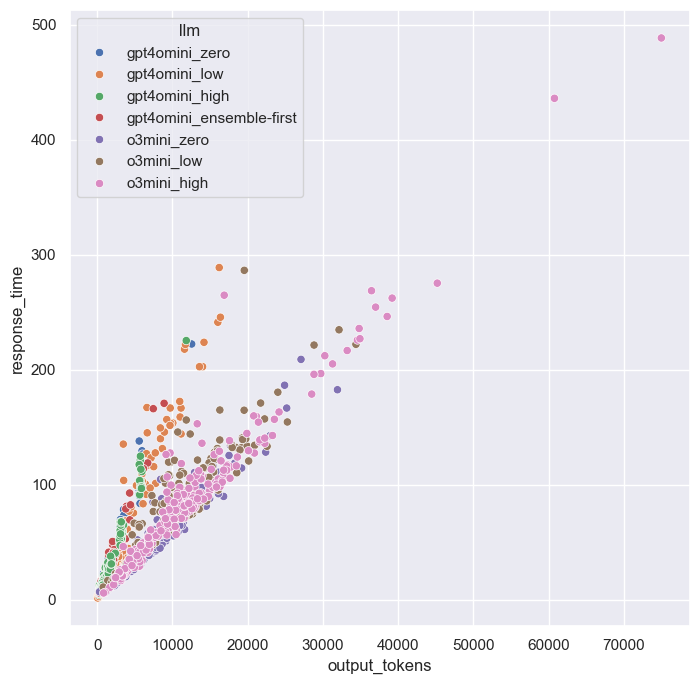

In [123]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x="output_tokens", y="response_time", hue="llm", data=initial, ax=ax, palette="deep")
plt.show()

### Total tokens

In [124]:
initial["total_tokens"] = initial["input_tokens"] + initial["output_tokens"]

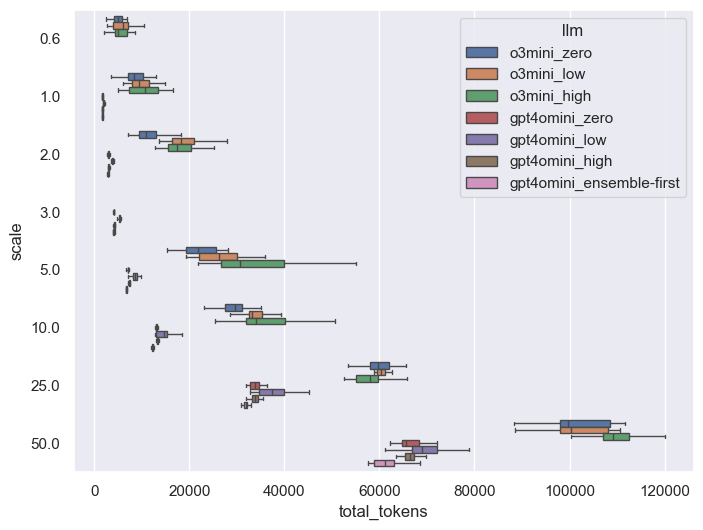

In [125]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="total_tokens", y="scale", hue="llm", data=initial, ax=ax, orient="h", showfliers=False)
plt.show()

### Drone states

In [126]:
initial["assigned_to_protection"] = initial["protecting"] + initial["moving_to_field"]

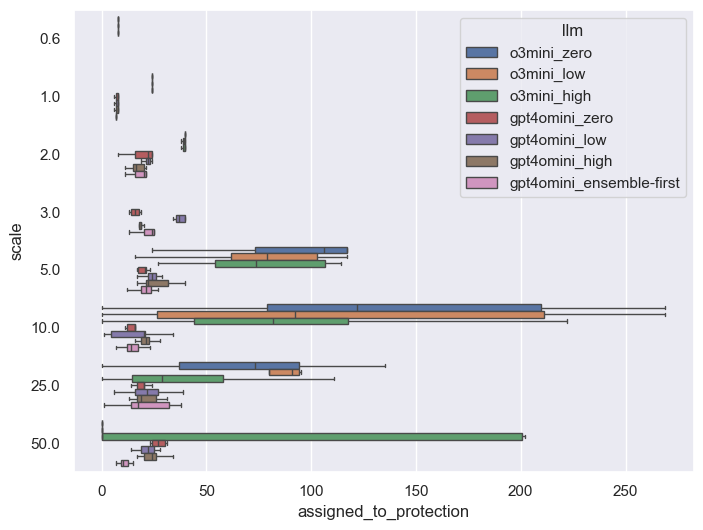

In [127]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="assigned_to_protection", y="scale", hue="llm", data=initial, ax=ax, orient="h", showfliers=False)
plt.show()

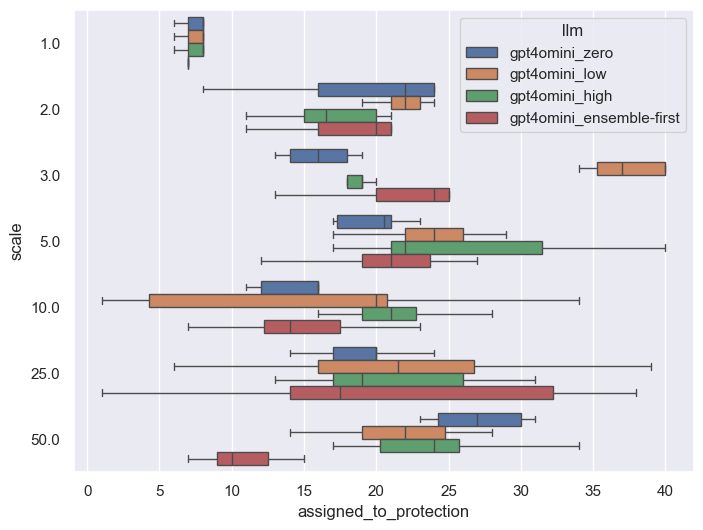

In [128]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="assigned_to_protection", y="scale", hue="llm", data=initial[initial["llm"].str.contains("gpt4omini")], ax=ax, orient="h", showfliers=False)
plt.show()

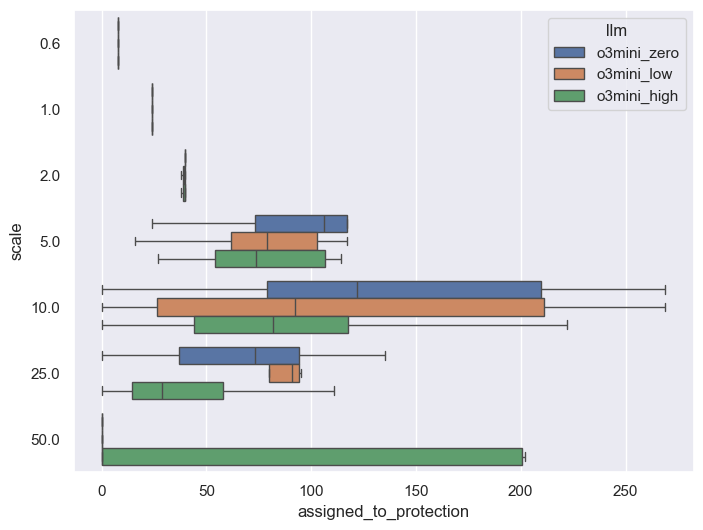

In [129]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="assigned_to_protection", y="scale", hue="llm", data=initial[initial["llm"].str.contains("o3mini")], ax=ax, orient="h", showfliers=False)
plt.show()

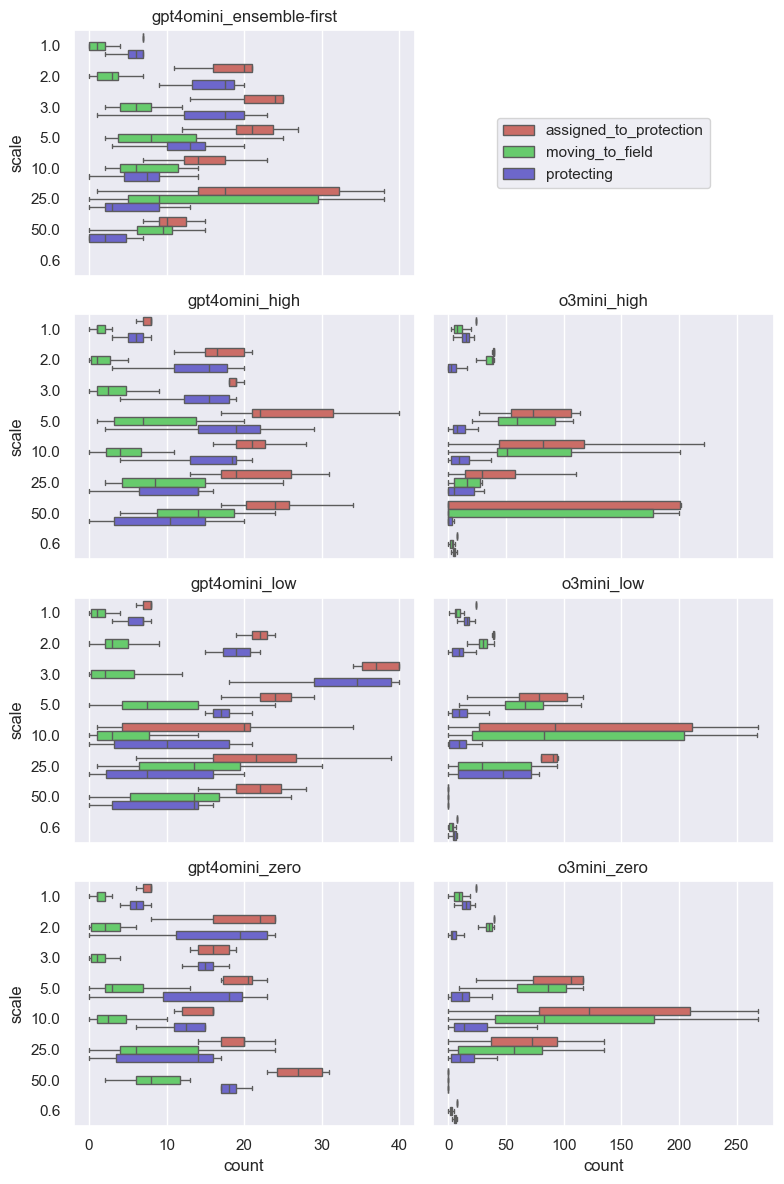

In [130]:
melted = pd.melt(
    initial,
    id_vars=["scale", "llm", "llm_variant", "llm_only"],
    value_vars=["assigned_to_protection", "moving_to_field", "protecting"],
    var_name="state",
    value_name="count"
)

fig, axes = plt.subplots(4, 2, figsize=(8, 12), sharey=True, sharex='col')
chart_data = list(melted.groupby("llm_variant"))
for i, ax in enumerate(axes.T.flatten()):
    if i == 4:
        continue
    if i > 4:
        i -= 1
    llm, group = chart_data[i]
    p = sns.boxplot(x="count", y="scale", hue="state", data=group, orient="h", ax=ax, showfliers=False, palette="hls", legend=i == 0)
    ax.set_title(llm)
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()
        axes[0, 1].legend(handles, labels, loc="center")
        axes[0, 1].set_axis_off()
plt.tight_layout()
plt.show()


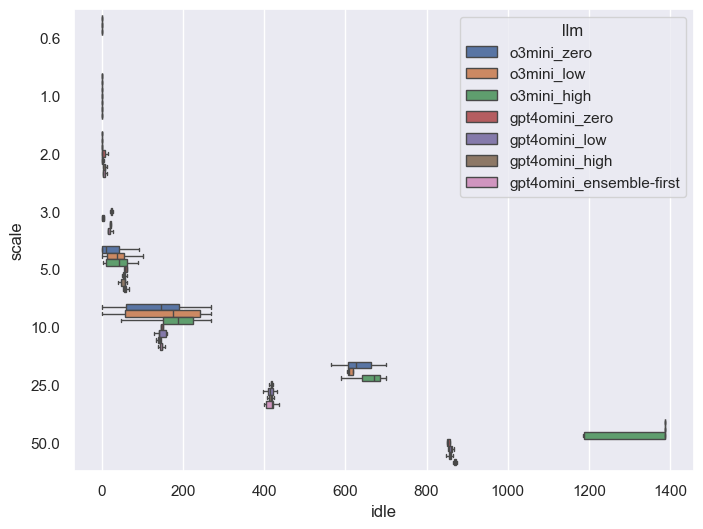

In [131]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="idle", y="scale", hue="llm", data=initial, ax=ax, orient="h", showfliers=False)
plt.show()

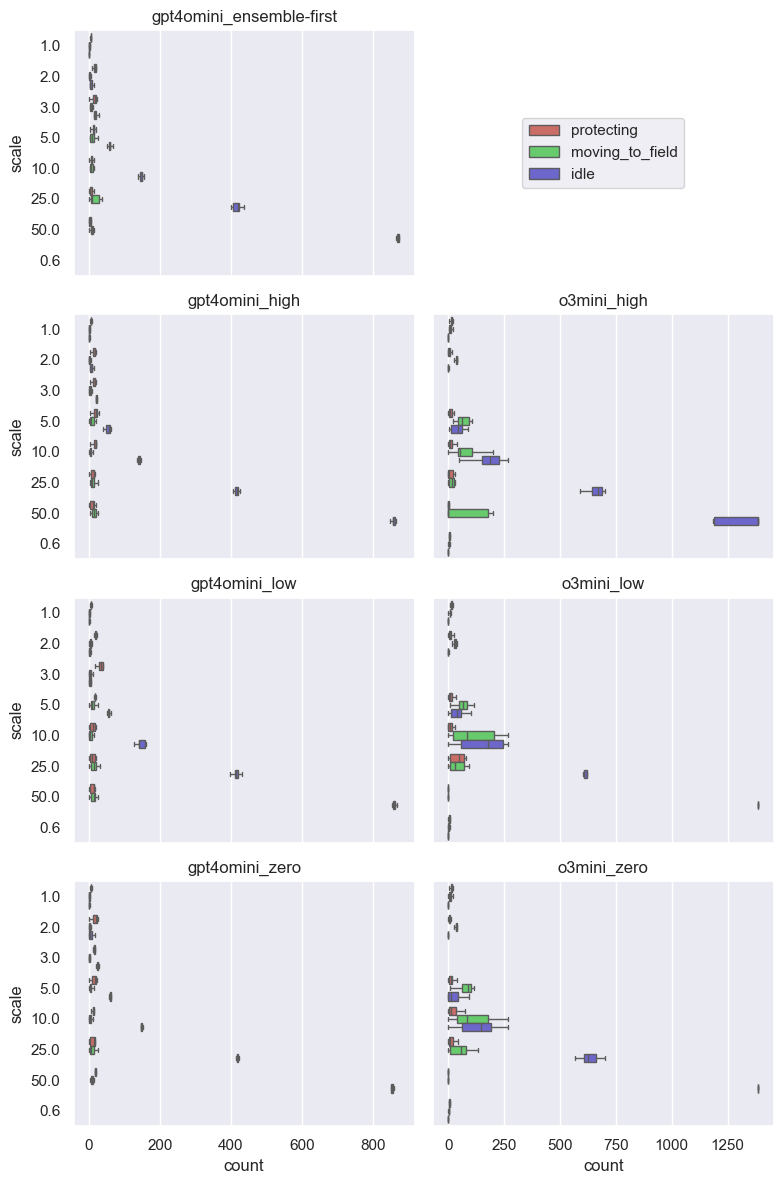

In [132]:
melted = pd.melt(
    initial,
    id_vars=["scale", "llm", "llm_variant"],
    value_vars=["protecting", "moving_to_field", "idle"],
    var_name="state",
    value_name="count"
)

fig, axes = plt.subplots(4, 2, figsize=(8, 12), sharey=True, sharex='col')
chart_data = list(melted.groupby("llm_variant"))
for i, ax in enumerate(axes.T.flatten()):
    if i == 4:
        continue
    if i > 4:
        i -= 1
    llm, group = chart_data[i]
    p = sns.boxplot(x="count", y="scale", hue="state", data=group, orient="h", ax=ax, showfliers=False, palette="hls", legend=i == 0)
    ax.set_title(llm)
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()
        axes[0, 1].legend(handles, labels, loc="center")
        axes[0, 1].set_axis_off()
plt.tight_layout()
plt.show()

In [133]:
# states = initial.groupby(["llm", "scale"]).agg({"idle": "mean", "protecting": "mean", "moving_to_field": "mean"}).reset_index()
states = initial.groupby(["llm", "scale"]).agg({"idle": "median", "protecting": statistics.median_low, "moving_to_field": "median", "assigned_to_protection": statistics.median_low}).reset_index()
states

,llm,scale,idle,protecting,moving_to_field,assigned_to_protection
0,gpt4omini_ensemble-first,1.0,1.0,6.0,1.0,7.0
1,gpt4omini_ensemble-first,2.0,4.0,17.0,3.0,20.0
2,gpt4omini_ensemble-first,3.0,16.0,17.0,6.0,24.0
3,gpt4omini_ensemble-first,5.0,58.0,13.0,8.0,21.0
4,gpt4omini_ensemble-first,10.0,148.0,7.0,6.0,14.0
5,gpt4omini_ensemble-first,25.0,419.5,3.0,9.0,17.0
6,gpt4omini_ensemble-first,50.0,871.0,2.0,9.5,10.0
7,gpt4omini_high,1.0,0.0,6.0,1.0,8.0
8,gpt4omini_high,2.0,7.5,15.0,1.0,16.0
9,gpt4omini_high,3.0,21.0,15.0,2.5,19.0


In [134]:
for _, row in states.iterrows():
    results.loc[(row['llm'], row['scale']), "assigned_to_protection"] = f"{row['assigned_to_protection']:.0f} ({row['assigned_to_protection'] / results.loc[(row['llm'], row['scale']), 'drones']:.0%})"
    results.loc[(row['llm'], row['scale']), "protecting"] = f"{row['protecting']:.0f} ({row['protecting'] / results.loc[(row['llm'], row['scale']), 'drones']:.0%})"

### Damage

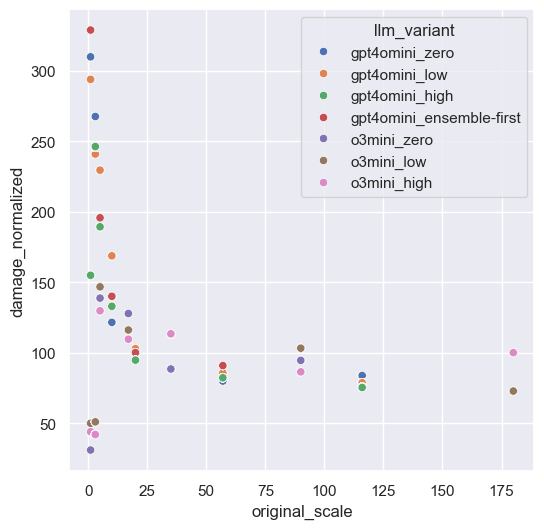

In [135]:
initial.loc[:,"damage_normalized"] = (initial["damage"] / initial["original_scale"])
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x="original_scale", y="damage_normalized", hue="llm_variant", data=initial, ax=ax, palette="deep")
plt.show()

### Cost

In [136]:
initial.loc[:,"output_only_tokens"] = initial["output_tokens"] - initial["reasoning_tokens"]

In [137]:
averages = initial.groupby(["llm", "scale"]).agg({"input_tokens": "mean", "output_only_tokens": "mean", "reasoning_tokens": "mean", "response_time": "mean"}).reset_index()
averages

,llm,scale,input_tokens,output_only_tokens,reasoning_tokens,response_time
0,gpt4omini_ensemble-first,1.0,1274.466667,417.633333,0.000000,7.775766
1,gpt4omini_ensemble-first,2.0,2423.666667,520.933333,0.000000,9.471521
2,gpt4omini_ensemble-first,3.0,3507.400000,588.733333,0.000000,9.820367
3,gpt4omini_ensemble-first,5.0,6122.166667,660.133333,0.000000,13.679626
4,gpt4omini_ensemble-first,10.0,11326.633333,962.466667,0.000000,15.558487
5,gpt4omini_ensemble-first,25.0,30136.666667,1791.733333,0.000000,30.075534
6,gpt4omini_ensemble-first,50.0,58538.500000,2890.100000,0.000000,57.695815
7,gpt4omini_high,1.0,1274.966667,424.700000,0.000000,8.975744
8,gpt4omini_high,2.0,2473.266667,577.333333,0.000000,10.794152
9,gpt4omini_high,3.0,3572.133333,654.633333,0.000000,10.526966


In [138]:
prices = {
    "gpt4omini": { "input": 0.15 / 1_000_000, "output": 0.6 / 1_000_000, "reasoning": 0 },
    "o3mini": { "input": 1.1 / 1_000_000, "output": 4.4 / 1_000_000, "reasoning": 4.4 / 1_000_000 },
}
for llm in initial["llm_variant"].unique():
    if llm in prices: continue
    llm_only = llm.split("_")[0]
    prices[llm] = prices[llm_only]

In [139]:
averages["input_cost"] = averages["input_tokens"] * averages["llm"].map(lambda llm: prices[llm]["input"])
averages["output_cost"] = averages["output_only_tokens"] * averages["llm"].map(lambda llm: prices[llm]["output"])
averages["reasoning_cost"] = averages["reasoning_tokens"] * averages["llm"].map(lambda llm: prices[llm]["reasoning"])

In [140]:
averages

,llm,scale,input_tokens,output_only_tokens,reasoning_tokens,response_time,input_cost,output_cost,reasoning_cost
0,gpt4omini_ensemble-first,1.0,1274.466667,417.633333,0.000000,7.775766,0.000191,0.000251,0.000000
1,gpt4omini_ensemble-first,2.0,2423.666667,520.933333,0.000000,9.471521,0.000364,0.000313,0.000000
2,gpt4omini_ensemble-first,3.0,3507.400000,588.733333,0.000000,9.820367,0.000526,0.000353,0.000000
3,gpt4omini_ensemble-first,5.0,6122.166667,660.133333,0.000000,13.679626,0.000918,0.000396,0.000000
4,gpt4omini_ensemble-first,10.0,11326.633333,962.466667,0.000000,15.558487,0.001699,0.000577,0.000000
5,gpt4omini_ensemble-first,25.0,30136.666667,1791.733333,0.000000,30.075534,0.004521,0.001075,0.000000
6,gpt4omini_ensemble-first,50.0,58538.500000,2890.100000,0.000000,57.695815,0.008781,0.001734,0.000000
7,gpt4omini_high,1.0,1274.966667,424.700000,0.000000,8.975744,0.000191,0.000255,0.000000
8,gpt4omini_high,2.0,2473.266667,577.333333,0.000000,10.794152,0.000371,0.000346,0.000000
9,gpt4omini_high,3.0,3572.133333,654.633333,0.000000,10.526966,0.000536,0.000393,0.000000


In [141]:
for _, row in averages.iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['input_cost']:.4f} + {row['output_cost']:.4f} + {row['reasoning_cost']:.4f}")

gpt4omini_ensemble-first, 1.0: 0.0002 + 0.0003 + 0.0000
gpt4omini_ensemble-first, 2.0: 0.0004 + 0.0003 + 0.0000
gpt4omini_ensemble-first, 3.0: 0.0005 + 0.0004 + 0.0000
gpt4omini_ensemble-first, 5.0: 0.0009 + 0.0004 + 0.0000
gpt4omini_ensemble-first, 10.0: 0.0017 + 0.0006 + 0.0000
gpt4omini_ensemble-first, 25.0: 0.0045 + 0.0011 + 0.0000
gpt4omini_ensemble-first, 50.0: 0.0088 + 0.0017 + 0.0000
gpt4omini_high, 1.0: 0.0002 + 0.0003 + 0.0000
gpt4omini_high, 2.0: 0.0004 + 0.0003 + 0.0000
gpt4omini_high, 3.0: 0.0005 + 0.0004 + 0.0000
gpt4omini_high, 5.0: 0.0010 + 0.0006 + 0.0000
gpt4omini_high, 10.0: 0.0018 + 0.0009 + 0.0000
gpt4omini_high, 25.0: 0.0047 + 0.0017 + 0.0000
gpt4omini_high, 50.0: 0.0093 + 0.0028 + 0.0000
gpt4omini_low, 1.0: 0.0002 + 0.0003 + 0.0000
gpt4omini_low, 2.0: 0.0004 + 0.0007 + 0.0000
gpt4omini_low, 3.0: 0.0006 + 0.0009 + 0.0000
gpt4omini_low, 5.0: 0.0010 + 0.0013 + 0.0000
gpt4omini_low, 10.0: 0.0018 + 0.0016 + 0.0000
gpt4omini_low, 25.0: 0.0047 + 0.0038 + 0.0000
gpt4omin

In [142]:
group_col = "llm"
# group_col = "llm_variant"
totals = (
    initial
    .groupby([group_col, "scale"])
    .agg({
        "input_tokens": "sum",
        "output_only_tokens": "sum",
        "reasoning_tokens": "sum",
        "response_time": "mean",
        group_col: "size"  # counts rows per group
    })
    .rename(columns={group_col: "row_count"})
    .reset_index()
)
totals["input_cost"] = totals["input_tokens"] * totals[group_col].map(lambda llm: prices[llm]["input"])
totals["output_cost"] = totals["output_only_tokens"] * totals[group_col].map(lambda llm: prices[llm]["output"])
totals["reasoning_cost"] = totals["reasoning_tokens"] * totals[group_col].map(lambda llm: prices[llm]["reasoning"])

totals["input_cost"] /= (totals["row_count"] / 30)
totals["output_cost"] /= (totals["row_count"] / 30)
totals["reasoning_cost"] /= (totals["row_count"] / 30)

for _, row in totals.iterrows():
    print(f"{row[group_col]}, {row['scale']}: {row['input_cost'] + row['output_cost'] + row['reasoning_cost']:.2f}")
    results.loc[(row[group_col], row['scale']), "cost"] = f"{row['input_cost'] + row['output_cost'] + row['reasoning_cost']:.2f}"

gpt4omini_ensemble-first, 1.0: 0.01
gpt4omini_ensemble-first, 2.0: 0.02
gpt4omini_ensemble-first, 3.0: 0.03
gpt4omini_ensemble-first, 5.0: 0.04
gpt4omini_ensemble-first, 10.0: 0.07
gpt4omini_ensemble-first, 25.0: 0.17
gpt4omini_ensemble-first, 50.0: 0.32
gpt4omini_high, 1.0: 0.01
gpt4omini_high, 2.0: 0.02
gpt4omini_high, 3.0: 0.03
gpt4omini_high, 5.0: 0.05
gpt4omini_high, 10.0: 0.08
gpt4omini_high, 25.0: 0.19
gpt4omini_high, 50.0: 0.36
gpt4omini_low, 1.0: 0.02
gpt4omini_low, 2.0: 0.03
gpt4omini_low, 3.0: 0.04
gpt4omini_low, 5.0: 0.07
gpt4omini_low, 10.0: 0.10
gpt4omini_low, 25.0: 0.26
gpt4omini_low, 50.0: 0.42
gpt4omini_zero, 1.0: 0.01
gpt4omini_zero, 2.0: 0.02
gpt4omini_zero, 3.0: 0.03
gpt4omini_zero, 5.0: 0.04
gpt4omini_zero, 10.0: 0.08
gpt4omini_zero, 25.0: 0.19
gpt4omini_zero, 50.0: 0.36
o3mini_high, 0.6: 0.62
o3mini_high, 1.0: 1.16
o3mini_high, 2.0: 2.09
o3mini_high, 5.0: 3.38
o3mini_high, 10.0: 3.20
o3mini_high, 25.0: 2.81
o3mini_high, 50.0: 4.63
o3mini_low, 0.6: 0.63
o3mini_low,

In [143]:
for _, row in averages.iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['response_time']:.1f}")
    results.loc[(row['llm'], row['scale']), "response_time"] = f"{row['response_time']:.1f}"

gpt4omini_ensemble-first, 1.0: 7.8
gpt4omini_ensemble-first, 2.0: 9.5
gpt4omini_ensemble-first, 3.0: 9.8
gpt4omini_ensemble-first, 5.0: 13.7
gpt4omini_ensemble-first, 10.0: 15.6
gpt4omini_ensemble-first, 25.0: 30.1
gpt4omini_ensemble-first, 50.0: 57.7
gpt4omini_high, 1.0: 9.0
gpt4omini_high, 2.0: 10.8
gpt4omini_high, 3.0: 10.5
gpt4omini_high, 5.0: 18.3
gpt4omini_high, 10.0: 25.3
gpt4omini_high, 25.0: 50.8
gpt4omini_high, 50.0: 87.2
gpt4omini_low, 1.0: 9.7
gpt4omini_low, 2.0: 17.7
gpt4omini_low, 3.0: 22.5
gpt4omini_low, 5.0: 33.3
gpt4omini_low, 10.0: 36.5
gpt4omini_low, 25.0: 111.6
gpt4omini_low, 50.0: 125.9
gpt4omini_zero, 1.0: 8.8
gpt4omini_zero, 2.0: 9.8
gpt4omini_zero, 3.0: 11.5
gpt4omini_zero, 5.0: 15.0
gpt4omini_zero, 10.0: 24.6
gpt4omini_zero, 25.0: 49.4
gpt4omini_zero, 50.0: 87.7
o3mini_high, 0.6: 27.7
o3mini_high, 1.0: 64.4
o3mini_high, 2.0: 113.6
o3mini_high, 5.0: 148.9
o3mini_high, 10.0: 130.1
o3mini_high, 25.0: 67.7
o3mini_high, 50.0: 81.8
o3mini_low, 0.6: 31.4
o3mini_low, 1

### CoT tokens

In [144]:
import tiktoken
encoding = tiktoken.encoding_for_model("gpt-4o")

In [145]:
answer = len(encoding.encode("<answer>\n</answer>"))
answer

6

In [146]:
protecting = len(encoding.encode("Drone_123: protecting Field_456"))
protecting

8

In [147]:
idle = len(encoding.encode("Drone_123: idle"))
idle

5

In [148]:
initial.loc[:,"answer_tokens"] = answer + (initial["protecting"] + initial["moving_to_field"]) * protecting + initial["idle"] * idle
initial.loc[:,"assigned_drones"] = None

In [149]:
ansi_files = sorted(results_folder.glob("*/*.ansi"))
import re

for file in ansi_files:
    try:
        name = file.stem
        if "jinja_" not in name:
            continue

        parts = name.split("_")
        llm = parts[1]
        scale = parts[-1].split(".")[0]
        params = parts[2:-1]
        params = ",\n".join(params)

        if "efcr" in params:
            variant = "ensemble-first"
        elif "strategy" in params:
            variant = "high"
        # elif "step-by-step" in params:
        elif "step-by-step" in params:
            if "V2" in params:
                variant = "low"
            else:
                continue
        else:
            variant = "zero"

        mask = (initial["llm"] == llm + "_" + variant) & (initial["original_scale_str"] == scale)

        log = file.read_text(encoding="utf-8")
        pattern = r"""

\[0m
\[36mRESPONSE:
(.*?)
\[0m
\[33mTOKENS USED:
.*?
\[0m"""
        matches = re.findall(pattern, log, re.DOTALL)
        answer_tokens_list = []
        assigned_drones_list = []
        for response in matches:
            answer_pattern = r"""<answer>.*?</answer>"""
            answer_match = re.findall(answer_pattern, response, re.DOTALL)
            answer_tokens_list.append(len(encoding.encode(answer_match[0])) if len(answer_match) > 0 else 0)

            if variant == "ensemble-first":
                assigned_drones = answer_match[0].count("Drone") if len(answer_match) > 0 else 0
            else:
                assigned_drones = answer_match[0].count("Drone") if len(answer_match) > 0 else 0
            assigned_drones_list.append(assigned_drones)

        initial.loc[mask,"answer_tokens"] = answer_tokens_list
        initial.loc[mask,"assigned_drones"] = assigned_drones_list

    except Exception as e:
        print(file.stem, e)

In [150]:
initial[["llm", "errors", "answer_tokens", "output_only_tokens", "output_tokens", "assigned_drones"]]

,llm,errors,answer_tokens,output_only_tokens,output_tokens,assigned_drones
0,gpt4omini_zero,0,66.0,423,423,8
1,gpt4omini_zero,0,72.0,453,453,8
2,gpt4omini_zero,0,75.0,457,457,8
3,gpt4omini_zero,0,78.0,333,333,8
4,gpt4omini_zero,0,75.0,524,524,8
...,...,...,...,...,...,...
2003,o3mini_high,1,4506.0,4521,8489,702
2005,o3mini_high,0,4242.0,4255,6879,700
2006,o3mini_high,0,4242.0,4255,6943,700
2007,o3mini_high,0,4242.0,4255,5791,700


In [151]:
initial.loc[:,"cot_tokens"] = initial["output_tokens"] - initial["answer_tokens"]
# no_errors = initial[initial["errors"] == 0]
no_errors = initial
for _, row in no_errors.groupby(["llm", "scale"]).agg({"cot_tokens": "mean"}).reset_index().iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['cot_tokens']:.0f}")
    results.loc[(row['llm'], row['scale']), "reasoning_tokens"] = f"{row['cot_tokens']:.0f}"  # TODO: Q1-Q3 instead of mean?

gpt4omini_ensemble-first, 1.0: 356
gpt4omini_ensemble-first, 2.0: 371
gpt4omini_ensemble-first, 3.0: 337
gpt4omini_ensemble-first, 5.0: 322
gpt4omini_ensemble-first, 10.0: 305
gpt4omini_ensemble-first, 25.0: 368
gpt4omini_ensemble-first, 50.0: 295
gpt4omini_high, 1.0: 349
gpt4omini_high, 2.0: 379
gpt4omini_high, 3.0: 356
gpt4omini_high, 5.0: 407
gpt4omini_high, 10.0: 431
gpt4omini_high, 25.0: 584
gpt4omini_high, 50.0: 853
gpt4omini_low, 1.0: 477
gpt4omini_low, 2.0: 910
gpt4omini_low, 3.0: 1115
gpt4omini_low, 5.0: 1562
gpt4omini_low, 10.0: 1771
gpt4omini_low, 25.0: 4394
gpt4omini_low, 50.0: 4989
gpt4omini_zero, 1.0: 398
gpt4omini_zero, 2.0: 365
gpt4omini_zero, 3.0: 319
gpt4omini_zero, 5.0: 269
gpt4omini_zero, 10.0: 349
gpt4omini_zero, 25.0: 459
gpt4omini_zero, 50.0: 516
o3mini_high, 0.6: 4285
o3mini_high, 1.0: 7924
o3mini_high, 2.0: 14535
o3mini_high, 5.0: 22074
o3mini_high, 10.0: 17216
o3mini_high, 25.0: 4829
o3mini_high, 50.0: 2261
o3mini_low, 0.6: 4353
o3mini_low, 1.0: 6829
o3mini_lo

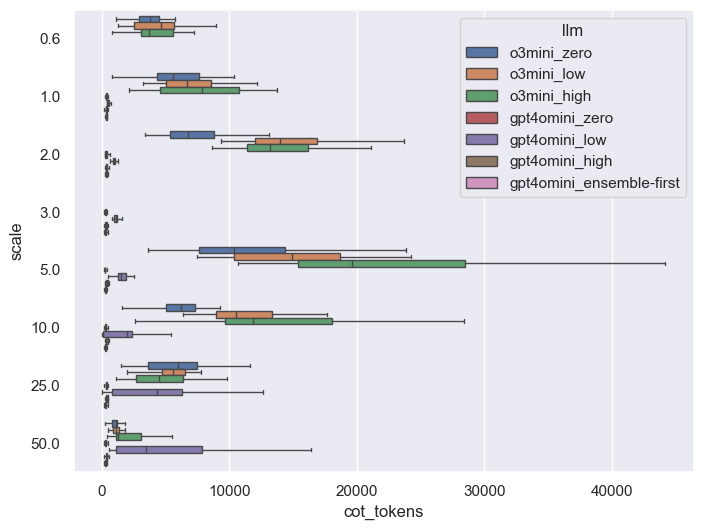

In [152]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="cot_tokens", y="scale", hue="llm", data=no_errors, ax=ax, orient="h", showfliers=False)
plt.show()

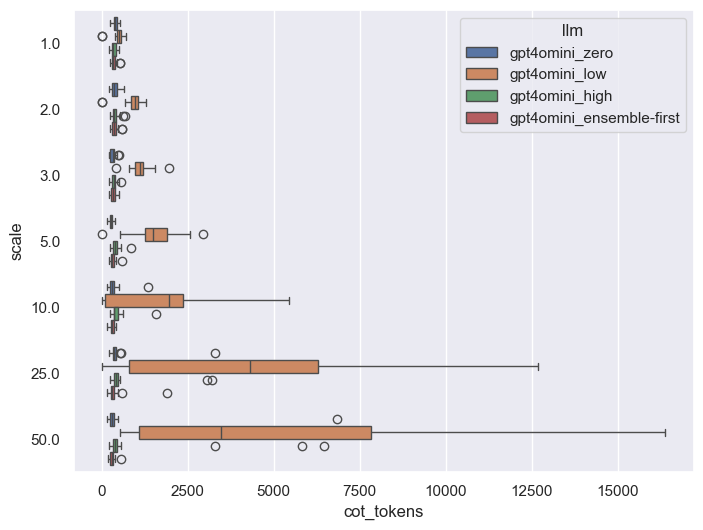

In [153]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x="cot_tokens", y="scale", hue="llm", data=no_errors[no_errors["llm"].str.contains("gpt4omini")], ax=ax, orient="h", showfliers=True)
plt.show()

### Answer tokens

In [154]:
for _, row in no_errors.groupby(["llm", "scale"]).agg({"answer_tokens": "mean", "assigned_drones": "mean"}).reset_index().iterrows():
    print(f"{row['llm']}, {row['scale']}: {row['answer_tokens']:.0f} ({row['assigned_drones']:.0f} lines)")
    results.loc[(row['llm'], row['scale']), "answer_tokens"] = f"{row['answer_tokens']:.0f}"
    results.loc[(row['llm'], row['scale']), "assigned_drones"] = f"{row['assigned_drones']:.0f} ({row['assigned_drones'] / results.loc[(row['llm'], row['scale']), 'drones']:.0%})"

gpt4omini_ensemble-first, 1.0: 62 (8 lines)
gpt4omini_ensemble-first, 2.0: 150 (23 lines)
gpt4omini_ensemble-first, 3.0: 252 (38 lines)
gpt4omini_ensemble-first, 5.0: 338 (71 lines)
gpt4omini_ensemble-first, 10.0: 658 (142 lines)
gpt4omini_ensemble-first, 25.0: 1424 (309 lines)
gpt4omini_ensemble-first, 50.0: 2595 (522 lines)
gpt4omini_high, 1.0: 76 (8 lines)
gpt4omini_high, 2.0: 198 (24 lines)
gpt4omini_high, 3.0: 299 (40 lines)
gpt4omini_high, 5.0: 557 (79 lines)
gpt4omini_high, 10.0: 1019 (158 lines)
gpt4omini_high, 25.0: 2245 (363 lines)
gpt4omini_high, 50.0: 3840 (628 lines)
gpt4omini_low, 1.0: 76 (8 lines)
gpt4omini_low, 2.0: 215 (24 lines)
gpt4omini_low, 3.0: 352 (40 lines)
gpt4omini_low, 5.0: 560 (78 lines)
gpt4omini_low, 10.0: 961 (151 lines)
gpt4omini_low, 25.0: 2019 (316 lines)
gpt4omini_low, 50.0: 2828 (460 lines)
gpt4omini_zero, 1.0: 76 (8 lines)
gpt4omini_zero, 2.0: 208 (24 lines)
gpt4omini_zero, 3.0: 294 (40 lines)
gpt4omini_zero, 5.0: 534 (79 lines)
gpt4omini_zero, 10.0

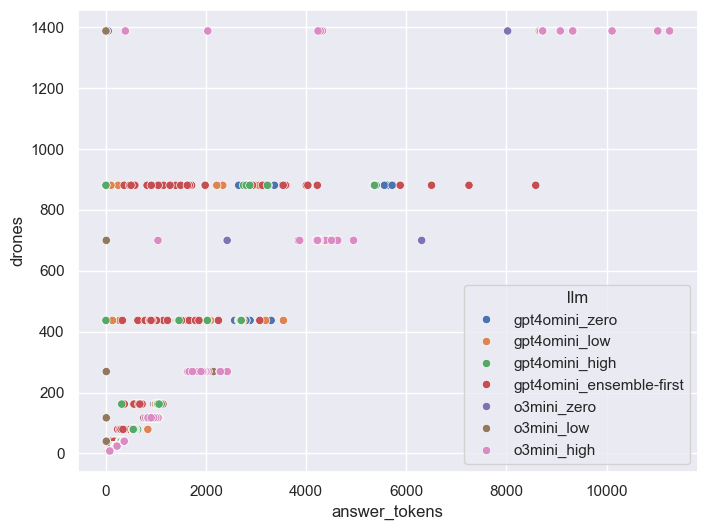

In [155]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x="answer_tokens", y="drones", hue="llm", data=no_errors, ax=ax, palette="deep")
plt.show()

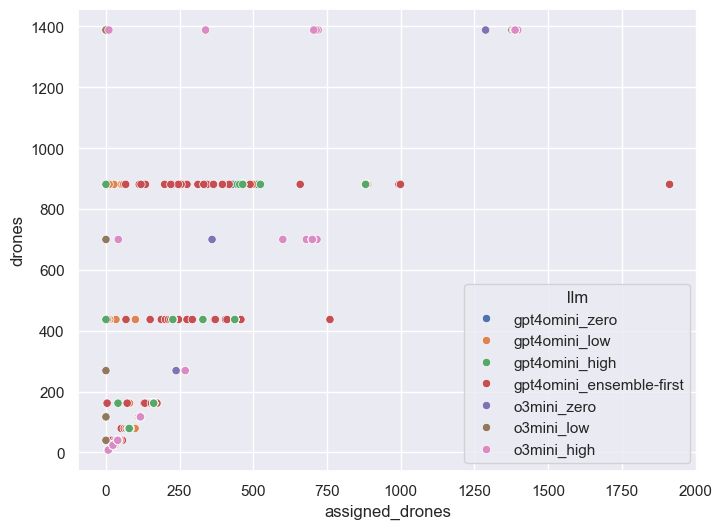

In [156]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x="assigned_drones", y="drones", hue="llm", data=no_errors, ax=ax, palette="deep")
plt.show()

### Response time for retries

In [157]:
repeated

,llm,scale,try,error_count,error_rate,response_time
42,gpt4omini_ensemble-first,1.0,1,13,0.433333,2.471428
43,gpt4omini_ensemble-first,1.0,2,8,0.266667,2.041910
50,gpt4omini_ensemble-first,2.0,1,23,0.766667,1.844524
51,gpt4omini_ensemble-first,2.0,2,7,0.233333,1.256474
52,gpt4omini_ensemble-first,3.0,1,29,0.966667,1.269715
...,...,...,...,...,...,...
63,o3mini_zero,10.0,2,0,0.000000,NaN
66,o3mini_zero,25.0,1,2,0.066667,34.996262
67,o3mini_zero,25.0,2,0,0.000000,NaN
60,o3mini_zero,50.0,1,2,0.066667,44.703919


In [158]:
initial_response_time = results[["response_time"]]
initial_response_time.index.names = ["llm", "scale"]
repeated_response_time = repeated[repeated["try"] == 1][["llm", "scale", "response_time"]].set_index(["llm", "scale"])
all_response_time = initial_response_time.join(repeated_response_time, lsuffix="_initial", rsuffix="_repeated")
all_response_time["retry/initial"] = all_response_time["response_time_repeated"] / all_response_time["response_time_initial"].astype(float)
all_response_time

response_time_initial  response_time_repeated  \
llm                      scale                                                 
gpt4omini_zero           1.0                     8.8                     NaN   
                         2.0                     9.8                     NaN   
                         3.0                    11.5                     NaN   
                         5.0                    15.0               10.332886   
                         10.0                   24.6               20.108685   
                         25.0                   49.4               46.349795   
                         50.0                   87.7               82.430223   
gpt4omini_low            1.0                     9.7                     NaN   
                         2.0                    17.7                3.176150   
                         3.0                    22.5                5.108966   
                         5.0                    33.3               11.489567   
                         10.0                   36.5               15.012132   
                         25.0                  111.6               47.240978   
                         50.0                  125.9               78.749783   
gpt4omini_high           1.0                     9.0                     NaN   
                         2.0                    10.8                     NaN   
                         3.0                    10.5                     NaN   
                         5.0                    18.3               15.234159   
                         10.0                   25.3               19.032728   
                         25.0                   50.8               47.758687   
                         50.0                   87.2               87.345365   
gpt4omini_ensemble-first 1.0                     7.8                2.471428   
                         2.0                     9.5                1.844524   
                         3.0                     9.8                1.269715   
                         5.0                    13.7                2.652137   
                         10.0                   15.6                6.334905   
                         25.0                   30.1               12.168925   
                         50.0                   57.7               22.216778   
o3mini_zero              0.6                    24.3                     NaN   
                         1.0                    48.8                     NaN   
                         2.0                    58.9                     NaN   
                         5.0                    83.5               58.449099   
                         10.0                   60.0               56.849843   
                         25.0                   70.8               34.996262   
                         50.0                   68.6               44.703919   
o3mini_low               0.6                    31.4                     NaN   
                         1.0                    65.3                     NaN   
                         2.0                   107.5               69.693445   
                         5.0                   118.4               49.363167   
                         10.0                   93.7               31.010758   
                         25.0                   85.6               83.845372   
                         50.0                   92.0               73.808810   
o3mini_high              0.6                    27.7                     NaN   
                         1.0                    64.4                     NaN   
                         2.0                   113.6                     NaN   
                         5.0                   148.9               45.975456   
                         10.0                  130.1               49.661699   
                         25.0                   67.7               76.380006   
                         50.0  

In [159]:
all_response_time.describe()

,response_time_repeated,retry/initial
count,34.000000,34.000000
mean,38.740288,0.594558
std,30.308520,0.308565
min,1.269715,0.129563
25%,11.659407,0.354204
50%,39.850091,0.559896
75%,58.049285,0.828707
max,104.103422,1.272658


### Results table

In [160]:
results

fields drones reasoning_tokens answer_tokens  \
llm                      scale                                                
gpt4omini_zero           1.0        4      8              398            76   
                         2.0       12     24              365           208   
                         3.0       20     40              319           294   
                         5.0       40     79              269           534   
                         10.0      80    162              349          1018   
                         25.0     228    437              459          2271   
                         50.0     464    881              516          4245   
gpt4omini_low            1.0        4      8              477            76   
                         2.0       12     24              910           215   
                         3.0       20     40             1115           352   
                         5.0       40     79             1562           560   
                         10.0      80    162             1771           961   
                         25.0     228    437             4394          2019   
                         50.0     464    881             4989          2828   
gpt4omini_high           1.0        4      8              349            76   
                         2.0       12     24              379           198   
                         3.0       20     40              356           299   
                         5.0       40     79              407           557   
                         10.0      80    162              431          1019   
                         25.0     228    437              584          2245   
                         50.0     464    881              853          3840   
gpt4omini_ensemble-first 1.0        4      8              356            62   
                         2.0       12     24              371           150   
                         3.0       20     40              337           252   
                         5.0       40     79              322           338   
                         10.0      80    162              305           658   
                         25.0     228    437              368          1424   
                         50.0     464    881              295          2595   
o3mini_zero              0.6        4      8             3798            78   
                         1.0       12     24             6072           222   
                         2.0       20     40             7360           365   
                         5.0       68    117            11166           990   
                         10.0     140    269             7680          2047   
                         25.0     360    700             6654          4317   
                         50.0     720   1388             1099          8410   
o3mini_low               0.6        4      8             4353            77   
                         1.0       12     24             6829           221   
                         2.0       20     40            14884           338   
                         5.0       68    117            15364           876   
                         10.0     140    269            11639          1922   
                         25.0     360    700             5718          4285   
                         50.0     720   1388             1515          7992   
o3mini_high              0.6        4      8             4285            77   
                         1.0       12     24             7924           222   
                         2.0       20     40            14535           364   
                         5.0       68    117            22074           937   
                         10.0     140    269            17216          1895   
                         25.0     360    700             4829          4203   
                         50.0     720   1388             2261          8076   

 

In [161]:
results_table = results.reset_index()
results_table[['llm', 'variant']] = results_table['llm'].str.split('_', n=1, expand=True)
results_table = results_table.set_index(['llm', 'variant'])
results_table


scale fields drones reasoning_tokens answer_tokens  \
llm       variant                                                              
gpt4omini zero              1.0      4      8              398            76   
          zero              2.0     12     24              365           208   
          zero              3.0     20     40              319           294   
          zero              5.0     40     79              269           534   
          zero             10.0     80    162              349          1018   
          zero             25.0    228    437              459          2271   
          zero             50.0    464    881              516          4245   
          low               1.0      4      8              477            76   
          low               2.0     12     24              910           215   
          low               3.0     20     40             1115           352   
          low               5.0     40     79             1562           560   
          low              10.0     80    162             1771           961   
          low              25.0    228    437             4394          2019   
          low              50.0    464    881             4989          2828   
          high              1.0      4      8              349            76   
          high              2.0     12     24              379           198   
          high              3.0     20     40              356           299   
          high              5.0     40     79              407           557   
          high             10.0     80    162              431          1019   
          high             25.0    228    437              584          2245   
          high             50.0    464    881              853          3840   
          ensemble-first    1.0      4      8              356            62   
          ensemble-first    2.0     12     24              371           150   
          ensemble-first    3.0     20     40              337           252   
          ensemble-first    5.0     40     79              322           338   
          ensemble-first   10.0     80    162              305           658   
          ensemble-first   25.0    228    437              368          1424   
          ensemble-first   50.0    464    881              295          2595   
o3mini    zero              0.6      4      8             3798            78   
          zero              1.0     12     24             6072           222   
          zero              2.0     20     40             7360           365   
          zero              5.0     68    117            11166           990   
          zero             10.0    140    269             7680          2047   
          zero             25.0    360    700             6654          4317   
          zero             50.0    720   1388             1099          8410   
          low               0.6      4      8             4353            77   
          low               1.0     12     24             6829           221   
          low               2.0     20     40            14884           338   
          low               5.0     68    117            15364           876   
          low              10.0    140    269            11639          1922   
          low              25.0    360    700             5718          4285   
          low              50.0    720   1388             1515          7992   
          high              0.6      4      8             4285            77   
          high              1.0     12     24             7924           222   
          high              2.0     20     40            14535           364   
          high              5.0     68    117            22074           937   
          high             10.0    140    269            17216          1895   
          high             25.0    360    700             4829          4203   
          high            

In [162]:
results_latex = []
last_llm = None
last_variant = None
for (llm, variant), row in results_table.iterrows():
    if pd.isna(row['drones']):  # skip rows without data
        continue

    scale_fmt = ".1f" if row['scale'] < 1 else ".0f"
    data = f"{row['fields']} & {row['drones']} & {row['scale']:{scale_fmt}}% & {row['reasoning_tokens']} & \\${row['cost']} & {row['retry_rate']} & {row['second_retry_rate']} & {row['assigned_drones']} & {row['assigned_to_protection']} & {row['response_time']}"

    if last_llm != llm:
        results_latex.append("\\hline")
        llm_rowspan = len(results_table.loc[llm])
        variant_rowspan = len(results_table.loc[(llm, variant)])
        results_latex.append(
            f"\\multirow{{{llm_rowspan}}}{{*}}{{{llm}}} & \\multirow{{{variant_rowspan}}}{{*}}{{{variant}}} & {data} \\\\")
        last_llm = llm
        last_variant = variant
    elif last_variant != variant:
        results_latex.append("\\cline{2-12}")
        variant_rowspan = len(results_table.loc[(llm, variant)])
        results_latex.append(
            f"& \\multirow{{{variant_rowspan}}}{{*}}{{{variant}}} & {data} \\\\")
        last_variant = variant
    else:
        results_latex.append(
            f"& & {data} \\\\")

result_latex = "\n".join(results_latex)
result_latex = result_latex.replace("%", "\\%")
result_latex = result_latex.replace("gpt4omini", "\\rotatebox[origin=c]{90}{GPT-4o mini}")
result_latex = result_latex.replace("o3mini", "\\rotatebox[origin=c]{90}{o3-mini}")
result_latex = result_latex.replace("zero", "\\rotatebox[origin=c]{90}{Zero strategy}")
result_latex = result_latex.replace("high", "\\rotatebox[origin=c]{90}{High-level strategy}")
result_latex = result_latex.replace("low", "\\rotatebox[origin=c]{90}{Low-level strategy}")
result_latex = result_latex.replace("ensemble-first", "\\rotatebox[origin=c]{90}{Ensemble-first}")
print(result_latex)


\hline
\multirow{28}{*}{\rotatebox[origin=c]{90}{GPT-4o mini}} & \multirow{7}{*}{\rotatebox[origin=c]{90}{Zero strategy}} & 4 & 8 & 1\% & 398 & \$0.01 & 0\% & 0\% & 8 (100\%) & 8 (100\%) & 8.8 \\
& & 12 & 24 & 2\% & 365 & \$0.02 & 0\% & 0\% & 24 (100\%) & 21 (88\%) & 9.8 \\
& & 20 & 40 & 3\% & 319 & \$0.03 & 0\% & 0\% & 40 (100\%) & 16 (40\%) & 11.5 \\
& & 40 & 79 & 5\% & 269 & \$0.04 & 3\% & 0\% & 79 (99\%) & 20 (25\%) & 15.0 \\
& & 80 & 162 & 10\% & 349 & \$0.08 & 7\% & 0\% & 162 (100\%) & 16 (10\%) & 24.6 \\
& & 228 & 437 & 25\% & 459 & \$0.19 & 60\% & 13\% & 362 (83\%) & 20 (5\%) & 49.4 \\
& & 464 & 881 & 50\% & 516 & \$0.36 & 73\% & 53\% & 680 (77\%) & 27 (3\%) & 87.7 \\
\cline{2-12}
& \multirow{7}{*}{\rotatebox[origin=c]{90}{Low-level strategy}} & 4 & 8 & 1\% & 477 & \$0.02 & 0\% & 0\% & 8 (100\%) & 8 (100\%) & 9.7 \\
& & 12 & 24 & 2\% & 910 & \$0.03 & 7\% & 0\% & 24 (100\%) & 22 (92\%) & 17.7 \\
& & 20 & 40 & 3\% & 1115 & \$0.04 & 3\% & 0\% & 40 (100\%) & 37 (92\%) & 22.5 \\
& &

C:\Users\micha\AppData\Local\Temp\ipykernel_30284\116268955.py:14: PerformanceWarning: indexing past lexsort depth may impact performance.
  variant_rowspan = len(results_table.loc[(llm, variant)])
C:\Users\micha\AppData\Local\Temp\ipykernel_30284\116268955.py:21: PerformanceWarning: indexing past lexsort depth may impact performance.
  variant_rowspan = len(results_table.loc[(llm, variant)])
